# Table of Contents 
* [Notebook Setup](#notebook-setup)
* [Time-Series Cross-Validation Split](#tscv)
* [Deep-Learning Models](#deep-learning-models)
    * [Simple RNN](#simple-RNN)
    * [LSTM-RNN](#LSTM-RNN)
    * [Feature-Subset LSTM-RNN](#subset-LSTM)
        * [Hyperparameter Tuning](#hyperparam-tuning)
            * [L2 Regularization](#L2-regularization)
            * [Dropout Tuning](#dropout-tuning)
            * [Learning Rate Adjustment](#lr-adj)
            * [Best Parameter LSTM](#best-params-lstm)

# Notebook Setup <a class="anchor" id="notebook-setup"></a>

In [1]:
pip install tensorflow


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: /Users/rg/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sklearn 
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import TimeSeriesSplit

In [3]:
X_train = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/X_train.csv')
y_train = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/y_train.csv')
X_test = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/X_test.csv')
y_test = pd.read_csv('/Users/rg/anaconda3/MSIN0097 - Predictive Analytics/y_test.csv')

In [61]:
#Function Definitions 

def create_sequences(data, time_steps):
    Xs = []
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
    return np.array(Xs)

# Time-Series Cross Validation Split <a class="anchor" id="tscv"></a>

In [5]:
# Initialize TimeSeriesSplit with 5 splits
tscv = TimeSeriesSplit(n_splits=5) #initialising 5 folds for cross-validation as in Notebook 2

# Applying TimeSeriesSplit to our training data
for train_index, test_index in tscv.split(X_train):
    X_train_rest, X_val = X_train.iloc[train_index], X_train.iloc[test_index]

for train_index, test_index in tscv.split(y_train): 
    y_train_rest, y_val = y_train.iloc[train_index], y_train.iloc[test_index]

# Deep-learning Models <a class="anchor" id="deep-learning-models"></a>

We will explore variations of the Recurrent Neural Network (RNN) for the purpose of this analysis.

In [6]:
#Setting global random seed 
import random
random.seed(42)
#Setting tf random seed
tf.random.set_seed(42)

In [62]:
X_train_rest.shape #checking shape of input data

(5035, 29)

Before passing the training, validation and test sets into the model we need to reshape into a 3D-array. 

In [140]:
#Defining the training dataset
data = X_train_rest

#Creating time-sequenced data using UDF
X_train_seq = create_sequences(data, n_steps)

X_train_seq.shape #code to check

X_val_seq = create_sequences(X_val, n_steps)

X_test_seq = create_sequences(X_test, n_steps)

#Dropping the same number instances to align y values with X values 
y_train_seq = y_train_rest[n_steps:]

y_val_seq = y_val[n_steps:]

y_test_seq = y_test[n_steps:]

#Converting df objects to np array
y_train_seq = y_train_seq.values

y_val_seq = y_val_seq.values

y_test_seq = y_test_seq.values

## Simple RNN <a class="anchor" id="simple-RNN"></a>

In [22]:
#Defining number of time steps
n_steps = 14

#Defining the number of features 
num_features = 29


#Defining the simple RNN model
simple_RNN = Sequential([
    SimpleRNN(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True),
    Dropout(0.20),
    SimpleRNN(128, activation='tanh', return_sequences=False),
    Dropout(0.20),
    Dense(1) 
])

#Compiling the model using the Adam optimizer and RMSE as metric
simple_RNN.compile(optimizer=Adam(), loss='mean_squared_error', metrics=[RootMeanSquaredError()])


#Fitting the model 
simple_RNN_history = simple_RNN.fit(X_train_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_seq, y_val_seq))


Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1.3455 - root_mean_squared_error: 1.1564 - val_loss: 3.5748 - val_root_mean_squared_error: 1.8907
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0159 - root_mean_squared_error: 1.0078 - val_loss: 3.0729 - val_root_mean_squared_error: 1.7530
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9771 - root_mean_squared_error: 0.9883 - val_loss: 3.8085 - val_root_mean_squared_error: 1.9515
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9327 - root_mean_squared_error: 0.9656 - val_loss: 3.9029 - val_root_mean_squared_error: 1.9756
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8691 - root_mean_squared_error: 0.9322 - val_loss: 3.2604 - val_root_mean_squared_error: 1.8057
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8126 - root_mean_squared_error: 0.9014 - val_loss: 3.9653 - val_root_mean_squared_error: 1.9913
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6732 - root_mean_squared_error: 0.8204 - val_loss: 3.3400 - val_root_mean_squared_error: 1.8276
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6751 - root_mean_squared_error: 0.8216 - val_loss: 3.4238 - val_root_mean_squared_error: 1.8504
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6756 - root_mean_squared_error: 0.8219 - val_loss: 3.3259 - val_root_mean_squared_error: 1.8237
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6770 - root_mean_squared_error: 0.8227 - val_loss: 3.3593 - val_root_mean_squared_error: 1.8328
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6745 - root_mean_squared_error: 0.8212 - val_loss: 3.2774 - val_root_mean_squared_error: 1.8103
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6747 - root_mean_squared_error: 0.8213 - val_loss: 3.4148 - val_root_mean_squared_error: 1.8479
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 

## LSTM-RNN <a class="anchor" id="lstm-RNN"></a>

In [21]:
#Defining number of time steps
n_steps = 14

#Defining the number of features 
num_features = 29

#Defining the LSTM model
lstm_model = Sequential([
    LSTM(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True),
    Dropout(0.20),
    LSTM(128, activation='tanh', return_sequences=False),
    Dropout(0.20),
    Dense(1)  
])

#Compiling 
lstm_model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=[RootMeanSquaredError()])


#Fitting the LSTM model 
lstm_history = lstm_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_seq, y_val_seq))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.7408 - root_mean_squared_error: 0.8604 - val_loss: 3.6267 - val_root_mean_squared_error: 1.9044
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.6951 - root_mean_squared_error: 0.8336 - val_loss: 3.8000 - val_root_mean_squared_error: 1.9494
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.6857 - root_mean_squared_error: 0.8280 - val_loss: 3.4086 - val_root_mean_squared_error: 1.8462
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.6816 - root_mean_squared_error: 0.8255 - val_loss: 3.4678 - val_root_mean_squared_error: 1.8622
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.6831 - root_mean_squared_error: 0.8263 - val_loss: 3.3641 - val_root_mean_squared_error: 1.8341
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.6786 - root_mean_squared_error: 0.8236 - val_loss: 3.1951 - val_root_mean_squared_error: 1.7875
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.6703 - root_mean_squared_error: 0.8186 - val_loss: 3.1275 - val_root_mean_squared_error: 1.7685
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.6703 - root_mean_squared_error: 0.8186 - val_loss: 3.1488 - val_root_mean_squared_error: 1.7745
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.6695 - root_mean_squared_error: 0.8181 - val_loss: 3.1412 - val_root_mean_squared_error: 1.7723
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.6702 - root_mean_squared_error: 0.8185 - val_loss: 3.1216 - val_root_mean_squared_error: 1.7668
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.6712 - root_mean_squared_error: 0.8191 - val_loss: 3.1383 - val_root_mean_squared_error: 1.7715
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.6703 - root_mean_squared_error: 0.8186 - val_loss: 3.1140 - val_root_mean_squared_error: 1.7646
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

## Feature-Subset LSTM-RNN  <a class="anchor" id="subset-LSTM"></a>

From the classical models developed previously, the relative importance of features towards model improvement was observed. We will now transfer this learning by fitting the LSTM-RNN on a subset of features. 

In [67]:
#Reducing feature set based on feature importance collected from classical models
X = X_train_rest[['Close_index_log_scaled', 'Low_index_log_scaled', 'Unemployment Rate (%)_log_scaled_pt_qt', 
             'Open_index_t-2_log_scaled', 'Open_index_t-1_log_scaled', 'Open_index_t-3_log_scaled', 
             'Open_index_t-4_log_scaled', 'Adj_Close_index_log_scaled', 'GDP per capita_log_scaled', 'Open_index_t-3_log_scaled', 
             'Open_index_t-3_log_scaled']]

#Reducing feature set in X_val and X_test as well 
X_val_reduced = X_val[['Close_index_log_scaled', 'Low_index_log_scaled', 'Unemployment Rate (%)_log_scaled_pt_qt', 
             'Open_index_t-2_log_scaled', 'Open_index_t-1_log_scaled', 'Open_index_t-3_log_scaled', 
             'Open_index_t-4_log_scaled', 'Adj_Close_index_log_scaled', 'GDP per capita_log_scaled', 'Open_index_t-3_log_scaled', 
             'Open_index_t-3_log_scaled']]

X_test_reduced = X_test[['Close_index_log_scaled', 'Low_index_log_scaled', 'Unemployment Rate (%)_log_scaled_pt_qt', 
             'Open_index_t-2_log_scaled', 'Open_index_t-1_log_scaled', 'Open_index_t-3_log_scaled', 
             'Open_index_t-4_log_scaled', 'Adj_Close_index_log_scaled', 'GDP per capita_log_scaled', 'Open_index_t-3_log_scaled', 
             'Open_index_t-3_log_scaled']]

In [75]:
#Creating sequences for the reduced feature sets with a 14-day time-step as before

X_seq = create_sequences(X, 14)
X_val_reduced_seq = create_sequences(X_val_reduced, 14)
X_test_reduced_seq = create_sequences(X_test_reduced, 14)

In [83]:
#Defining number of time steps
n_steps = 14

#Defining the number of features 
num_features = 11

#Defining the LSTM model
subset_lstm_model = Sequential([
    LSTM(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True),
    Dropout(0.20),
    LSTM(128, activation='tanh', return_sequences=False),
    Dropout(0.20),
    Dense(1)  
])

#Compiling the subset-LSTM model
subset_lstm_model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=[RootMeanSquaredError()])

#Fitting the LSTM model on the reduced with early stopping callback
subset_lstm_history = subset_lstm_model.fit(X_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_reduced_seq, y_val_seq))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0563 - root_mean_squared_error: 0.2164 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0344
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0042 - root_mean_squared_error: 0.0646 - val_loss: 0.0036 - val_root_mean_squared_error: 0.0599
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0043 - root_mean_squared_error: 0.0657 - val_loss: 0.0056 - val_root_mean_squared_error: 0.0750
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0039 - root_mean_squared_error: 0.0623 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0591
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0039 - root_mean_squared_error: 0.0621 - val_loss: 0.0027 - val_root_mean_squared_error: 0.0516
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0035 - root_mean_squared_error: 0.0590 - val_loss: 0.0046 - val_root_mean_squared_error: 0.0676
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss:

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0029 - root_mean_squared_error: 0.0537 - val_loss: 0.0054 - val_root_mean_squared_error: 0.0735
Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0027 - root_mean_squared_error: 0.0521 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0618
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0026 - root_mean_squared_error: 0.0512 - val_loss: 0.0064 - val_root_mean_squared_error: 0.0798
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0022 - root_mean_squared_error: 0.0469 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0512
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0023 - root_mean_squared_error: 0.0478 - val_loss: 0.0042 - val_root_mean_squared_error: 0.0645
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0029 - root_mean_squared_error: 0.0540 - val_loss: 2.1220e-04 - val_root_mean_squared_error: 0.0146
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 

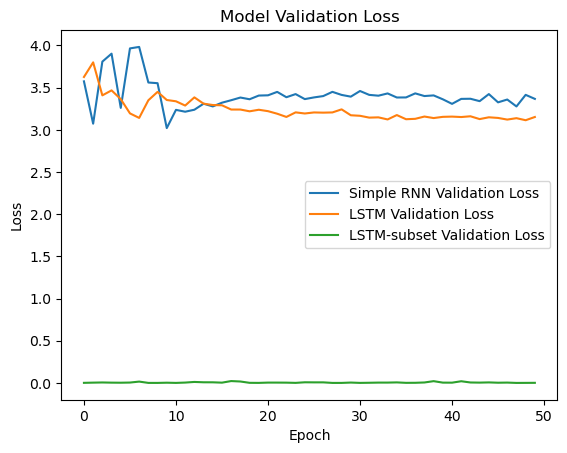

In [84]:
#Plotting validation loss over epochs of RNN, LSTM-RNN, LSTM-subset models 
plt.plot(simple_RNN_history.history['val_loss'], label='Simple RNN Validation Loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss')
plt.plot(subset_lstm_history.history['val_loss'], label='LSTM-subset Validation Loss')
plt.title('Model Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

We see that by reducing the feature space, the LSTM model produces a drastically improved result. 

### Hyperparameter Tuning  <a class="anchor" id="hyperparam-tuning"></a>

We shall now attempt to improve the performance of the LSTM-subset model using three methods - L2 regularization, Dropout tuning and Learning Rate Adjustment. 

#### L2 Regularization <a class="anchor" id="l2-regularization"></a>

We will apply the L2 regularization to the LSTM-subset model with stacked LSTM layers. 

In [91]:
#Defining number of time steps
n_steps = 14

#Defining the number of features 
num_features = 11

#Defining the LSTM model
regularized_lstm_model = Sequential([
    LSTM(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True,
         kernel_regularizer=l2(0.01)),
    Dropout(0.20),
    LSTM(128, activation='tanh', return_sequences=False,
         kernel_regularizer=l2(0.01)),
    Dropout(0.20),
    Dense(1)
])

#Compiling the subset-LSTM model
regularized_lstm_model.compile(optimizer=Adam(), loss='mean_squared_error', metrics=[RootMeanSquaredError()])

#Fitting the regularized LSTM model 
regularized_lstm_history = regularized_lstm_model.fit(X_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_reduced_seq, y_val_seq))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 2.4242 - root_mean_squared_error: 0.2432 - val_loss: 0.4265 - val_root_mean_squared_error: 0.2093
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.2677 - root_mean_squared_error: 0.0705 - val_loss: 0.0958 - val_root_mean_squared_error: 0.0899
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0740 - root_mean_squared_error: 0.0707 - val_loss: 0.0482 - val_root_mean_squared_error: 0.1238
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0324 - root_mean_squared_error: 0.0728 - val_loss: 0.0272 - val_root_mean_squared_error: 0.1094
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0199 - root_mean_squared_error: 0.0808 - val_loss: 0.0218 - val_root_mean_squared_error: 0.1144
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0140 - root_mean_squared_error: 0.0787 - val_loss: 0.0125 - val_root_mean_squared_error: 0.0798
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0067 - root_mean_squared_error: 0.0705 - val_loss: 0.0508 - val_root_mean_squared_error: 0.2214
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0067 - root_mean_squared_error: 0.0692 - val_loss: 0.0024 - val_root_mean_squared_error: 0.0244
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0052 - root_mean_squared_error: 0.0590 - val_loss: 0.0385 - val_root_mean_squared_error: 0.1921
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0074 - root_mean_squared_error: 0.0748 - val_loss: 0.0500 - val_root_mean_squared_error: 0.2197
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0058 - root_mean_squared_error: 0.0638 - val_loss: 0.0112 - val_root_mean_squared_error: 0.0980
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0058 - root_mean_squared_error: 0.0650 - val_loss: 0.0098 - val_root_mean_squared_error: 0.0905
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

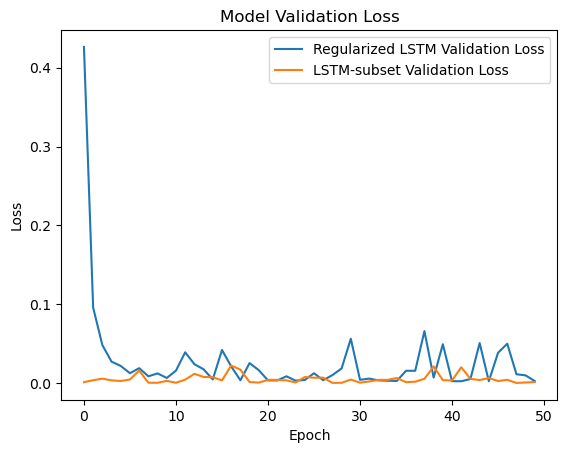

In [92]:
#Plotting validation loss over epochs of both LSTM models 
plt.plot(regularized_lstm_history.history['val_loss'], label='Regularized LSTM Validation Loss')
plt.plot(subset_lstm_history.history['val_loss'], label='LSTM-subset Validation Loss')
plt.title('Model Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

We observe that the regularized LSTM initially produces a significantly higher loss than the baseline subset model but over the epochs converges to about the same level. We would ideally like to see a smoother loss function than what the regularized model has produced. 

#### Dropout Tuning <a class="anchor" id="dropout-tuning"></a>

We will now experiment with different dropout rates, holding the regularizer as well. 

In [105]:
n_steps = 14 
num_features = 11  

#Creating a list of dropout rates 
dropouts = [0.2, 0.35, 0.5] #Increasing dropout by 0.15 at each step

#Initialising an empty dict  
histories = {}

# Writing a for loop to create a different model for each dropout rate
for dropout_rate in dropouts:
    dropout_lstm_model = Sequential([
        LSTM(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True,
             kernel_regularizer=l2(0.01)),  
        Dropout(dropout_rate),
        LSTM(128, activation='tanh', return_sequences=False,
             kernel_regularizer=l2(0.01)),  
        Dropout(dropout_rate),
        Dense(1)
    ])
    # Compiling within loop
    dropout_lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[RootMeanSquaredError()])
    # Fitting within loop
    history = dropout_lstm_model.fit(X_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_reduced_seq, y_val_seq))
    #Adding history for select dropout rate to the histories dict 
    histories[dropout_rate] = history

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.5373 - root_mean_squared_error: 0.2982 - val_loss: 0.5101 - val_root_mean_squared_error: 0.2243
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.3317 - root_mean_squared_error: 0.0717 - val_loss: 0.1431 - val_root_mean_squared_error: 0.1500
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1014 - root_mean_squared_error: 0.0697 - val_loss: 0.0763 - val_root_mean_squared_error: 0.1691
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0470 - root_mean_squared_error: 0.0830 - val_loss: 0.0299 - val_root_mean_squared_error: 0.0843
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0256 - root_mean_squared_error: 0.0769 - val_loss: 0.0186 - val_root_mean_squared_error: 0.0770
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0175 - root_mean_squared_error: 0.0794 - val_loss: 0.0176 - val_root_mean_squared_error: 0.0960
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0067 - root_mean_squared_error: 0.0696 - val_loss: 0.0125 - val_root_mean_squared_error: 0.1033
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0097 - root_mean_squared_error: 0.0880 - val_loss: 0.0033 - val_root_mean_squared_error: 0.0336
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0055 - root_mean_squared_error: 0.0588 - val_loss: 0.0614 - val_root_mean_squared_error: 0.2441
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0059 - root_mean_squared_error: 0.0635 - val_loss: 0.0246 - val_root_mean_squared_error: 0.1516
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0064 - root_mean_squared_error: 0.0682 - val_loss: 0.0081 - val_root_mean_squared_error: 0.0799
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0055 - root_mean_squared_error: 0.0616 - val_loss: 0.0181 - val_root_mean_squared_error: 0.1280
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step 

Epoch 37/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0093 - root_mean_squared_error: 0.0838 - val_loss: 0.2272 - val_root_mean_squared_error: 0.4740
Epoch 38/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0121 - root_mean_squared_error: 0.0968 - val_loss: 0.0776 - val_root_mean_squared_error: 0.2742
Epoch 39/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0120 - root_mean_squared_error: 0.0967 - val_loss: 0.0198 - val_root_mean_squared_error: 0.1316
Epoch 40/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0111 - root_mean_squared_error: 0.0920 - val_loss: 0.0095 - val_root_mean_squared_error: 0.0861
Epoch 41/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0089 - root_mean_squared_error: 0.0819 - val_loss: 0.0118 - val_root_mean_squared_error: 0.0977
Epoch 42/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0092 - root_mean_squared_error: 0.0827 - val_loss: 0.0348 - val_root_mean_squared_error: 0.1803
Epoch 43/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step 

Epoch 30/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0150 - root_mean_squared_error: 0.1085 - val_loss: 0.0180 - val_root_mean_squared_error: 0.1221
Epoch 31/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0135 - root_mean_squared_error: 0.1021 - val_loss: 0.0888 - val_root_mean_squared_error: 0.2930
Epoch 32/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0149 - root_mean_squared_error: 0.1078 - val_loss: 0.0118 - val_root_mean_squared_error: 0.0936
Epoch 33/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0144 - root_mean_squared_error: 0.1054 - val_loss: 0.0347 - val_root_mean_squared_error: 0.1775
Epoch 34/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0140 - root_mean_squared_error: 0.1043 - val_loss: 0.0456 - val_root_mean_squared_error: 0.2063
Epoch 35/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0131 - root_mean_squared_error: 0.1001 - val_loss: 0.1440 - val_root_mean_squared_error: 0.3759
Epoch 36/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step 

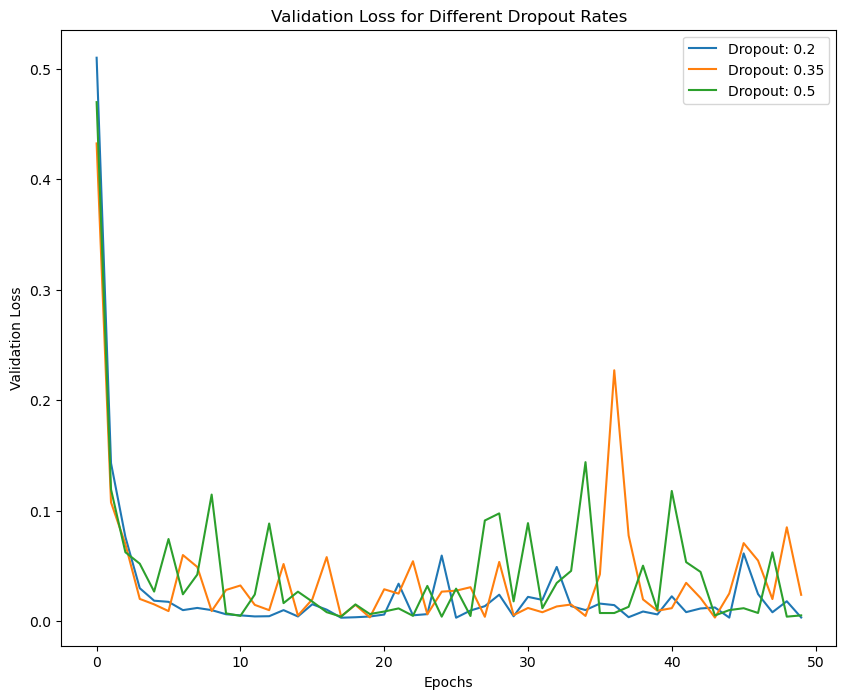

In [106]:
#Plotting the validation loss across different dropout LSTMs
plt.figure(figsize=(10, 8))

for dropout_rate, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'Dropout: {dropout_rate}')

plt.title('Validation Loss for Different Dropout Rates')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

We observe that the original dropout rate of 0.2 has the smoothest loss curve, with almost all of the dropout rates tested convering to the same loss over the epochs. 

#### Learning Rate Adjustment <a class="anchor" id="lr-adj"></a>

Finally, we shall attempt to tune the LSTM-subset model by adjusting the learning rate. 

In [108]:
#Creating a list of learning rates 
learning_rates = [0.01, 0.001, 0.0001] #Decreasing the learning rate by a factor 

#Initializing a dict to store histories from different learning-rate LSTMs
histories_lr = {}


#Writing a for loop over the defined learning rates
for lr in learning_rates:
    lr_lstm_model = Sequential([
        LSTM(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True, 
             kernel_regularizer=l2(0.01)), #with L2 regularizer
        Dropout(0.2), #with best dropout 
        LSTM(128, activation='tanh', return_sequences=False, kernel_regularizer=l2(0.01)), 
        Dropout(0.2),
        Dense(1)
    ])

#Compiling the model with a specific learning rate
    lr_lstm_model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=[RootMeanSquaredError()])

#Fitting the model and store the history
    history_lr = lr_lstm_model.fit(X_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_reduced_seq, y_val_seq))
    histories_lr[lr] = history_lr


Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 2.5530 - root_mean_squared_error: 0.7766 - val_loss: 0.2818 - val_root_mean_squared_error: 0.4409
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0682 - root_mean_squared_error: 0.1200 - val_loss: 0.1316 - val_root_mean_squared_error: 0.3427
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0284 - root_mean_squared_error: 0.1273 - val_loss: 0.3065 - val_root_mean_squared_error: 0.5458
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0211 - root_mean_squared_error: 0.1123 - val_loss: 0.2360 - val_root_mean_squared_error: 0.4813
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0147 - root_mean_squared_error: 0.1002 - val_loss: 0.1326 - val_root_mean_squared_error: 0.3560
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0130 - root_mean_squared_error: 0.0883 - val_loss: 0.1419 - val_root_mean_squared_error: 0.3722
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0081 - root_mean_squared_error: 0.0712 - val_loss: 0.2648 - val_root_mean_squared_error: 0.5118
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0068 - root_mean_squared_error: 0.0639 - val_loss: 0.2513 - val_root_mean_squared_error: 0.4990
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0066 - root_mean_squared_error: 0.0637 - val_loss: 0.2263 - val_root_mean_squared_error: 0.4727
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0068 - root_mean_squared_error: 0.0642 - val_loss: 0.2115 - val_root_mean_squared_error: 0.4571
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0087 - root_mean_squared_error: 0.0746 - val_loss: 0.2651 - val_root_mean_squared_error: 0.5120
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0069 - root_mean_squared_error: 0.0642 - val_loss: 0.1990 - val_root_mean_squared_error: 0.4430
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

Epoch 37/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0063 - root_mean_squared_error: 0.0662 - val_loss: 0.0089 - val_root_mean_squared_error: 0.0847
Epoch 38/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0063 - root_mean_squared_error: 0.0675 - val_loss: 0.0215 - val_root_mean_squared_error: 0.1402
Epoch 39/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0066 - root_mean_squared_error: 0.0688 - val_loss: 0.0967 - val_root_mean_squared_error: 0.3079
Epoch 40/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0091 - root_mean_squared_error: 0.0832 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0302
Epoch 41/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0056 - root_mean_squared_error: 0.0614 - val_loss: 0.0199 - val_root_mean_squared_error: 0.1351
Epoch 42/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0052 - root_mean_squared_error: 0.0593 - val_loss: 0.0186 - val_root_mean_squared_error: 0.1306
Epoch 43/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

Epoch 30/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0124 - root_mean_squared_error: 0.0626 - val_loss: 0.0309 - val_root_mean_squared_error: 0.1515
Epoch 31/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0116 - root_mean_squared_error: 0.0620 - val_loss: 0.0246 - val_root_mean_squared_error: 0.1317
Epoch 32/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0108 - root_mean_squared_error: 0.0610 - val_loss: 0.0344 - val_root_mean_squared_error: 0.1669
Epoch 33/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0112 - root_mean_squared_error: 0.0686 - val_loss: 0.0138 - val_root_mean_squared_error: 0.0873
Epoch 34/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0105 - root_mean_squared_error: 0.0667 - val_loss: 0.0218 - val_root_mean_squared_error: 0.1267
Epoch 35/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0098 - root_mean_squared_error: 0.0648 - val_loss: 0.0164 - val_root_mean_squared_error: 0.1050
Epoch 36/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step 

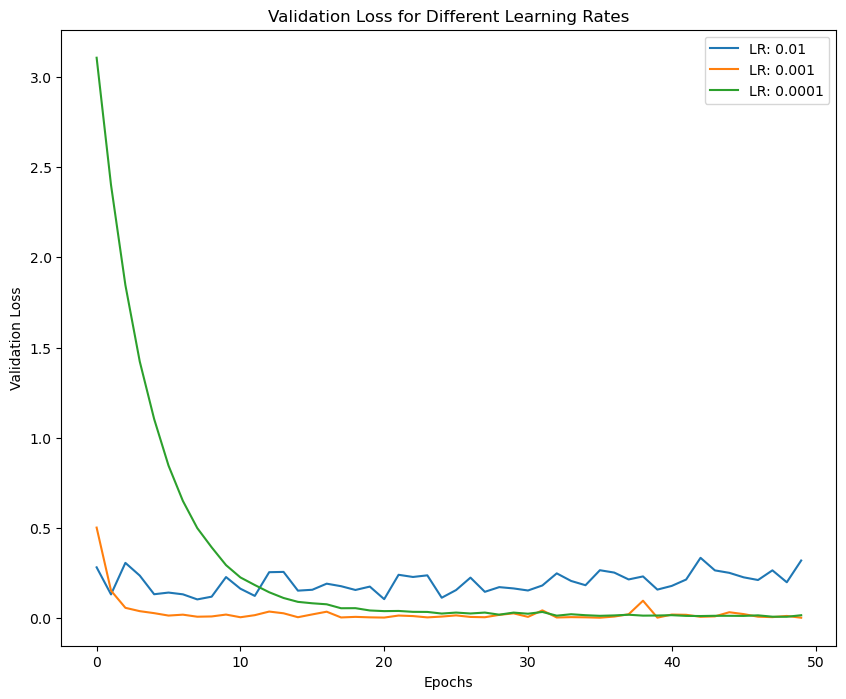

In [111]:
#Plotting the validation loss for each learning rate
plt.figure(figsize=(10, 8))
for lr, history_lr in histories_lr.items():
    plt.plot(history_lr.history['val_loss'], label=f'LR: {lr}')

plt.title('Validation Loss for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

We observe that a learning rate of 0.1 appears to be too large as it is unable to reach the global minima at any point over the epochs. Conversely, a learning rate of 0.0001 takes a longer time to converge to the global minima and does not seem to improve the model performance in terms of loss minimization. 

#### Best Parameter LSTM  <a class="anchor" id="best-params-lstm"></a>

In [123]:
n_steps = 14

num_features = 11 

lr = 0.001 

#Defining the model with best params
best_param_lstm_model = Sequential([
        LSTM(256, activation='tanh', input_shape=(n_steps, num_features), return_sequences=True, 
             kernel_regularizer=l2(0.01)), #with L2 regularizer
        Dropout(0.2), #with dropout 
        LSTM(128, activation='tanh', return_sequences=False, kernel_regularizer=l2(0.01)), 
        Dropout(0.2), 
        Dense(1)
    ])

#Compiling the model with all the best params
best_param_lstm_model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=[RootMeanSquaredError()])

#Fitting the model 
history_best_param_lstm = best_param_lstm_model.fit(X_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_val_reduced_seq, y_val_seq))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 2.5220 - root_mean_squared_error: 0.3004 - val_loss: 0.4904 - val_root_mean_squared_error: 0.1988
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.3269 - root_mean_squared_error: 0.0722 - val_loss: 0.1431 - val_root_mean_squared_error: 0.1412
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.1058 - root_mean_squared_error: 0.0783 - val_loss: 0.0651 - val_root_mean_squared_error: 0.1173
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0483 - root_mean_squared_error: 0.0736 - val_loss: 0.0358 - val_root_mean_squared_error: 0.1068
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0261 - root_mean_squared_error: 0.0726 - val_loss: 0.0362 - val_root_mean_squared_error: 0.1516
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0170 - root_mean_squared_error: 0.0729 - val_loss: 0.0185 - val_root_mean_squared_error: 0.1027
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0057 - root_mean_squared_error: 0.0617 - val_loss: 0.0332 - val_root_mean_squared_error: 0.1771
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0059 - root_mean_squared_error: 0.0634 - val_loss: 0.0073 - val_root_mean_squared_error: 0.0742
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0054 - root_mean_squared_error: 0.0599 - val_loss: 0.0051 - val_root_mean_squared_error: 0.0588
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0056 - root_mean_squared_error: 0.0622 - val_loss: 0.0179 - val_root_mean_squared_error: 0.1270
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0054 - root_mean_squared_error: 0.0604 - val_loss: 0.0273 - val_root_mean_squared_error: 0.1600
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0059 - root_mean_squared_error: 0.0651 - val_loss: 0.0062 - val_root_mean_squared_error: 0.0680
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step 

We observe that the default values for learning and dropout rates perform the best on the validation data, while the addition of the L2 regularizer does not improve on the baseline performance either. 

In [118]:
#Evaluating the LSTM-subset on test data 

subset_lstm_test_history = subset_lstm_model.fit(X_seq, y_train_seq, epochs=50, batch_size=64, validation_data=(X_test_reduced_seq, y_test_seq))

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0021 - root_mean_squared_error: 0.0462 - val_loss: 0.0639 - val_root_mean_squared_error: 0.2528
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0024 - root_mean_squared_error: 0.0485 - val_loss: 0.2187 - val_root_mean_squared_error: 0.4677
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0022 - root_mean_squared_error: 0.0466 - val_loss: 0.0573 - val_root_mean_squared_error: 0.2394
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0023 - root_mean_squared_error: 0.0481 - val_loss: 0.1417 - val_root_mean_squared_error: 0.3764
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0025 - root_mean_squared_error: 0.0495 - val_loss: 0.0635 - val_root_mean_squared_error: 0.2520
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0025 - root_mean_squared_error: 0.0502 - val_loss: 0.1600 - val_root_mean_squared_error: 0.4000
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss:

Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0021 - root_mean_squared_error: 0.0461 - val_loss: 0.1887 - val_root_mean_squared_error: 0.4344
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0022 - root_mean_squared_error: 0.0473 - val_loss: 0.2318 - val_root_mean_squared_error: 0.4814
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0021 - root_mean_squared_error: 0.0458 - val_loss: 0.1217 - val_root_mean_squared_error: 0.3489
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0017 - root_mean_squared_error: 0.0413 - val_loss: 0.3566 - val_root_mean_squared_error: 0.5971
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0020 - root_mean_squared_error: 0.0446 - val_loss: 0.5894 - val_root_mean_squared_error: 0.7677
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0021 - root_mean_squared_error: 0.0454 - val_loss: 0.3984 - val_root_mean_squared_error: 0.6312
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step 

In [131]:
# Evaluating each model on the test set
simple_RNN_test_eval = simple_RNN.evaluate(X_test_seq, y_test_seq, verbose=1)
lstm_test_eval = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=1)
subset_lstm_test_eval = subset_lstm_model.evaluate(X_test_reduced_seq, y_test_seq, verbose=1)
best_param_lstm_test_eval = best_param_lstm_model.evaluate(X_test_reduced_seq, y_test_seq, verbose=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.5615 - root_mean_squared_error: 2.7370
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2867 - root_mean_squared_error: 2.6864
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1467 - root_mean_squared_error: 0.3445
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0410 - root_mean_squared_error: 0.1984


In [133]:
#Creating a list with the RMSE scores of different LSTM models b
RMSE_lstm = [
    simple_RNN_test_eval[1],  
    lstm_test_eval[1],
    subset_lstm_test_eval[1],
    best_param_lstm_test_eval[1]
]

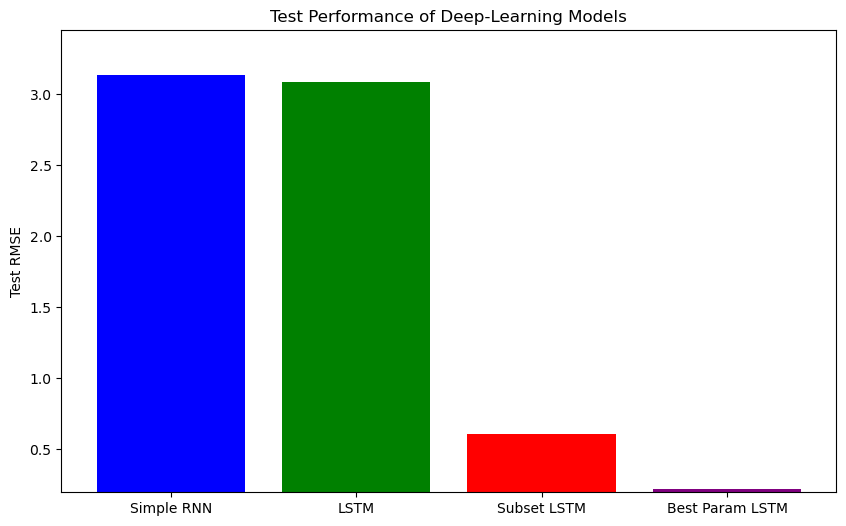

In [135]:
#Plotting the test RMSE of different models

model_names = ['Simple RNN', 'LSTM', 'Subset LSTM', 'Best Param LSTM']

plt.figure(figsize=(10, 6))
plt.bar(model_names, RMSE_lstm, color=['blue', 'green', 'red', 'purple'])
plt.title('Test Performance of Deep-Learning Models')
plt.ylabel('Test RMSE')
plt.ylim([min(RMSE_lstm) * 0.9, max(RMSE_lstm) * 1.1])  

plt.show()

We conclude that the test performance has been considerably improved through the hyperparameter tuning and feature subsetting.  

In [139]:
change_in_RMSE = (subset_lstm_test_eval[1]-best_param_lstm_test_eval[1]) / subset_lstm_test_eval[1]
change_in_RMSE

0.6426296673458196